#**Can We Trust HR AI?**
An Experimental Study of Data Quality and Model Robustness in Employee Attrition Prediction

## Problem Statement

Employee attrition prediction models are often evaluated on clean datasets,
yet real-world HR data frequently contains missing values, noise, and outliers.

This study investigates how data quality degradation affects the reliability
and robustness of machine learning models used for employee attrition prediction.

## Research Questions

RQ1: Which type of data quality issue causes the greatest degradation in predictive performance?

RQ2: Which machine learning model is most robust under degraded data conditions?

RQ3: Which employee attributes contribute most strongly to attrition prediction?

RQ4: How does predictive reliability change as degradation severity increases?

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


## Dataset

The IBM HR Analytics Employee Attrition Dataset was used for this study.

Target Variable:
- Attrition (Yes / No)

The dataset contains demographic, compensation, career progression, and workplace-related features that may influence employee turnover.



In [6]:
csv_file_path = f"{path}/WA_Fn-UseC_-HR-Employee-Attrition.csv"
data = pd.read_csv(csv_file_path)
data.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
data.shape

(1470, 35)

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [49]:
data.duplicated().sum()

np.int64(0)

<Axes: xlabel='Attrition', ylabel='count'>

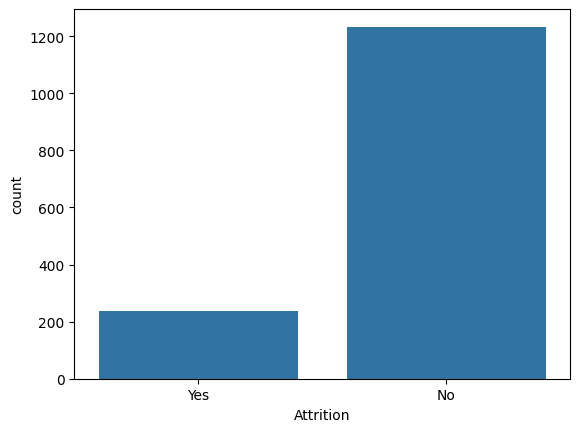

In [9]:
sns.countplot(x ='Attrition',
              data = data)

### Attrition Distribution

The count plot above clearly shows that the dataset is imbalanced, with a significantly higher number of employees choosing not to leave ('No') compared to those who do ('Yes'). This imbalance is crucial to consider during model training and evaluation.

In [10]:
data['Attrition'].value_counts(normalize=True)*100

,proportion
Attrition,
No,83.877551
Yes,16.122449


In [11]:
data.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


## Exploratory Data Analysis

EDA was performed to understand class distribution, feature characteristics, and potential data quality issues.

Key observations:

- Attrition is an imbalanced classification problem.
- Numerical features exhibit varying scales.
- Several variables show skewed distributions.
- Certain compensation and tenure-related variables appear strongly associated with attrition.

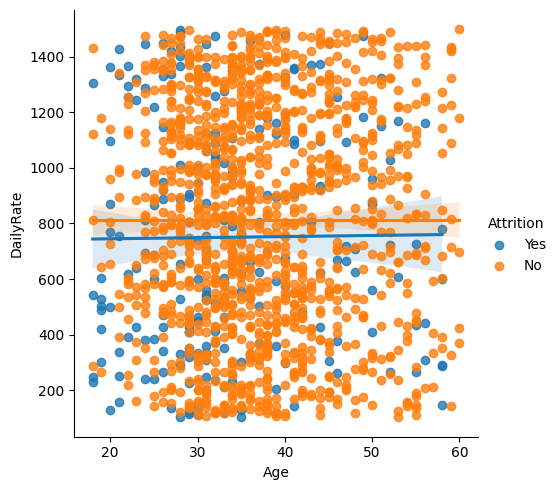

In [12]:
sns.lmplot(x = 'Age',
           y = 'DailyRate',
           hue = 'Attrition',
           data = data)

### Age vs Daily Rate by Attrition

This scatter plot with a linear model trend line indicates the relationship between `Age`, `DailyRate`, and `Attrition`. While no strong linear separation is immediately apparent, the plot helps visualize the distribution of these variables across the attrition groups.

<Axes: xlabel='Attrition', ylabel='MonthlyIncome'>

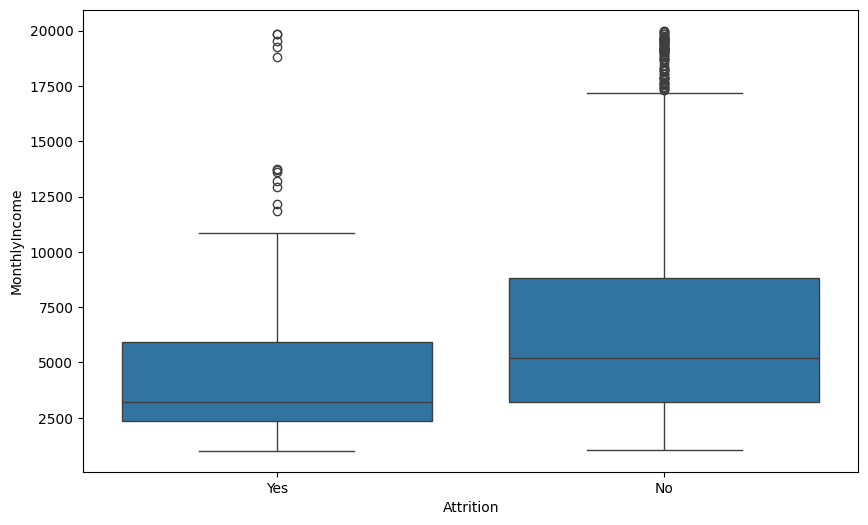

In [13]:
plt.figure(figsize =(10, 6))
sns.boxplot(y ='MonthlyIncome',
            x ='Attrition',
            data = data)

### Monthly Income vs Attrition

The box plot illustrates the distribution of `MonthlyIncome` for employees who attrited versus those who did not. It suggests that employees with lower monthly incomes are more prone to attrition, while those with very high incomes tend to stay, as evidenced by the outliers and the overall distribution.

### Age Distribution

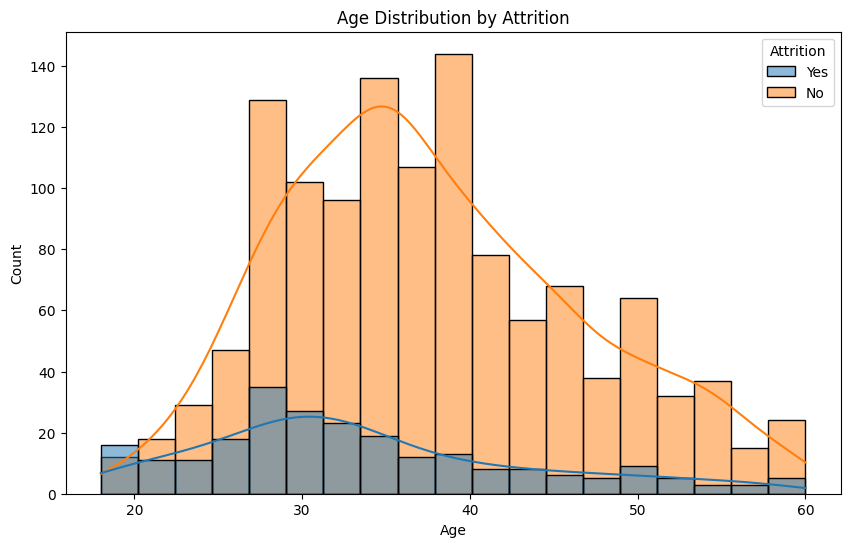

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Age', hue='Attrition', kde=True)
plt.title('Age Distribution by Attrition')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Age Distribution by Attrition

This histogram shows the distribution of employee `Age` for both attrition groups. It highlights that younger employees (e.g., in their late 20s and early 30s) tend to have a higher attrition rate compared to older employees, which aligns with common workforce trends.

### Monthly Income Distribution

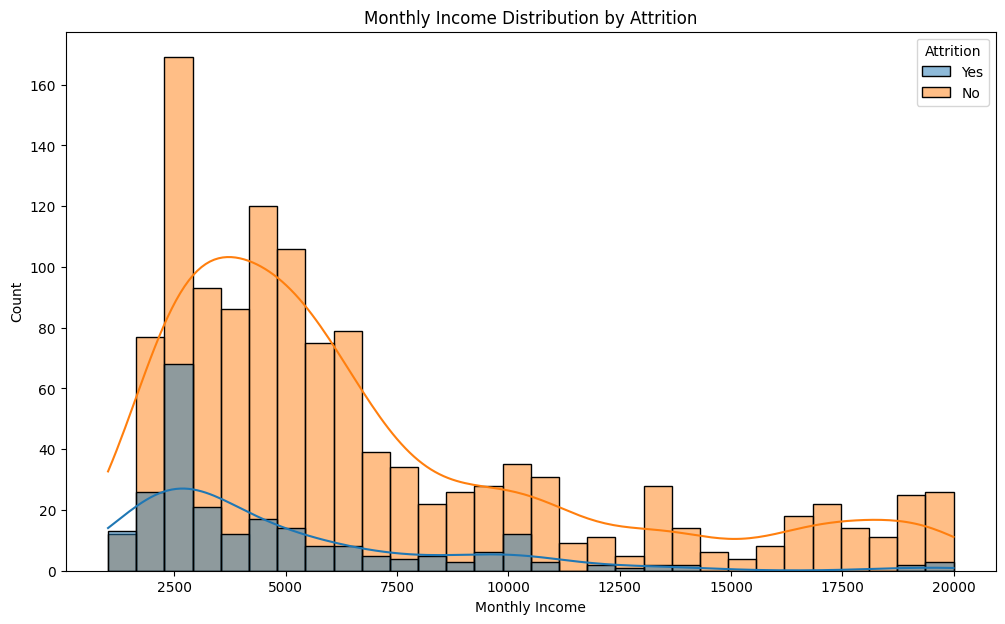

In [15]:
plt.figure(figsize=(12, 7))
sns.histplot(data=data, x='MonthlyIncome', hue='Attrition', kde=True, bins=30)
plt.title('Monthly Income Distribution by Attrition')
plt.xlabel('Monthly Income')
plt.ylabel('Count')
plt.show()

### Monthly Income Distribution by Attrition

Similar to the box plot, this histogram provides a more detailed view of the `MonthlyIncome` distribution. It reinforces the observation that attrition is more prevalent among lower-income employees, with a noticeable peak for 'Yes' attrition at lower income brackets.

### Overtime vs Attrition

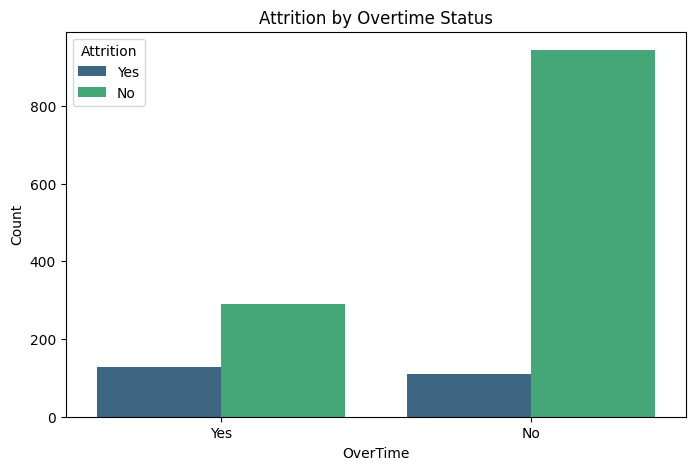

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='OverTime', hue='Attrition', data=data, palette='viridis')
plt.title('Attrition by Overtime Status')
plt.xlabel('OverTime')
plt.ylabel('Count')
plt.show()

### Overtime vs Attrition

The count plot clearly indicates that employees who work `OverTime` have a significantly higher attrition rate than those who do not. This suggests that work-life balance and workload might be critical factors influencing an employee's decision to leave.

### Job Satisfaction vs Attrition

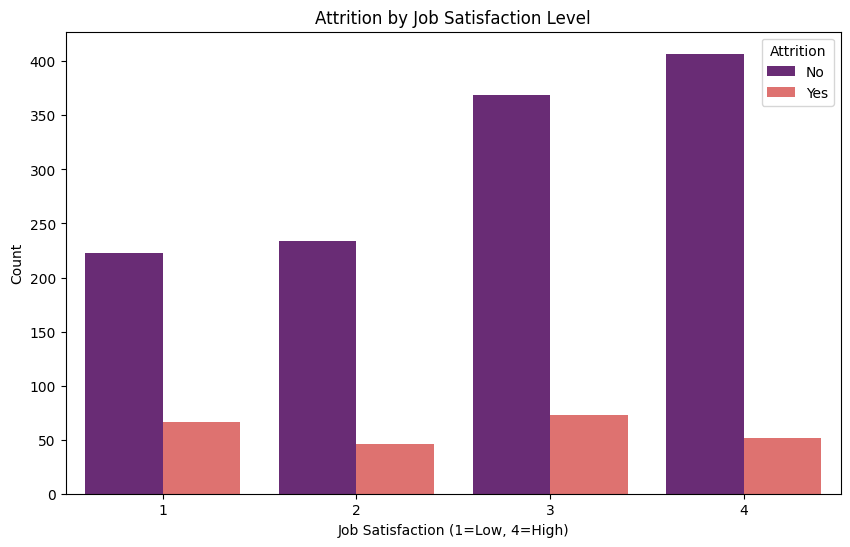

In [17]:
plt.figure(figsize=(10, 6))
sns.countplot(x='JobSatisfaction', hue='Attrition', data=data, palette='magma')
plt.title('Attrition by Job Satisfaction Level')
plt.xlabel('Job Satisfaction (1=Low, 4=High)')
plt.ylabel('Count')
plt.show()

### Job Satisfaction vs Attrition

This count plot shows that lower levels of `JobSatisfaction` (ratings 1 and 2) are associated with a higher proportion of attrition. Conversely, employees with higher job satisfaction (ratings 3 and 4) are more likely to stay.

### Correlation Heatmap

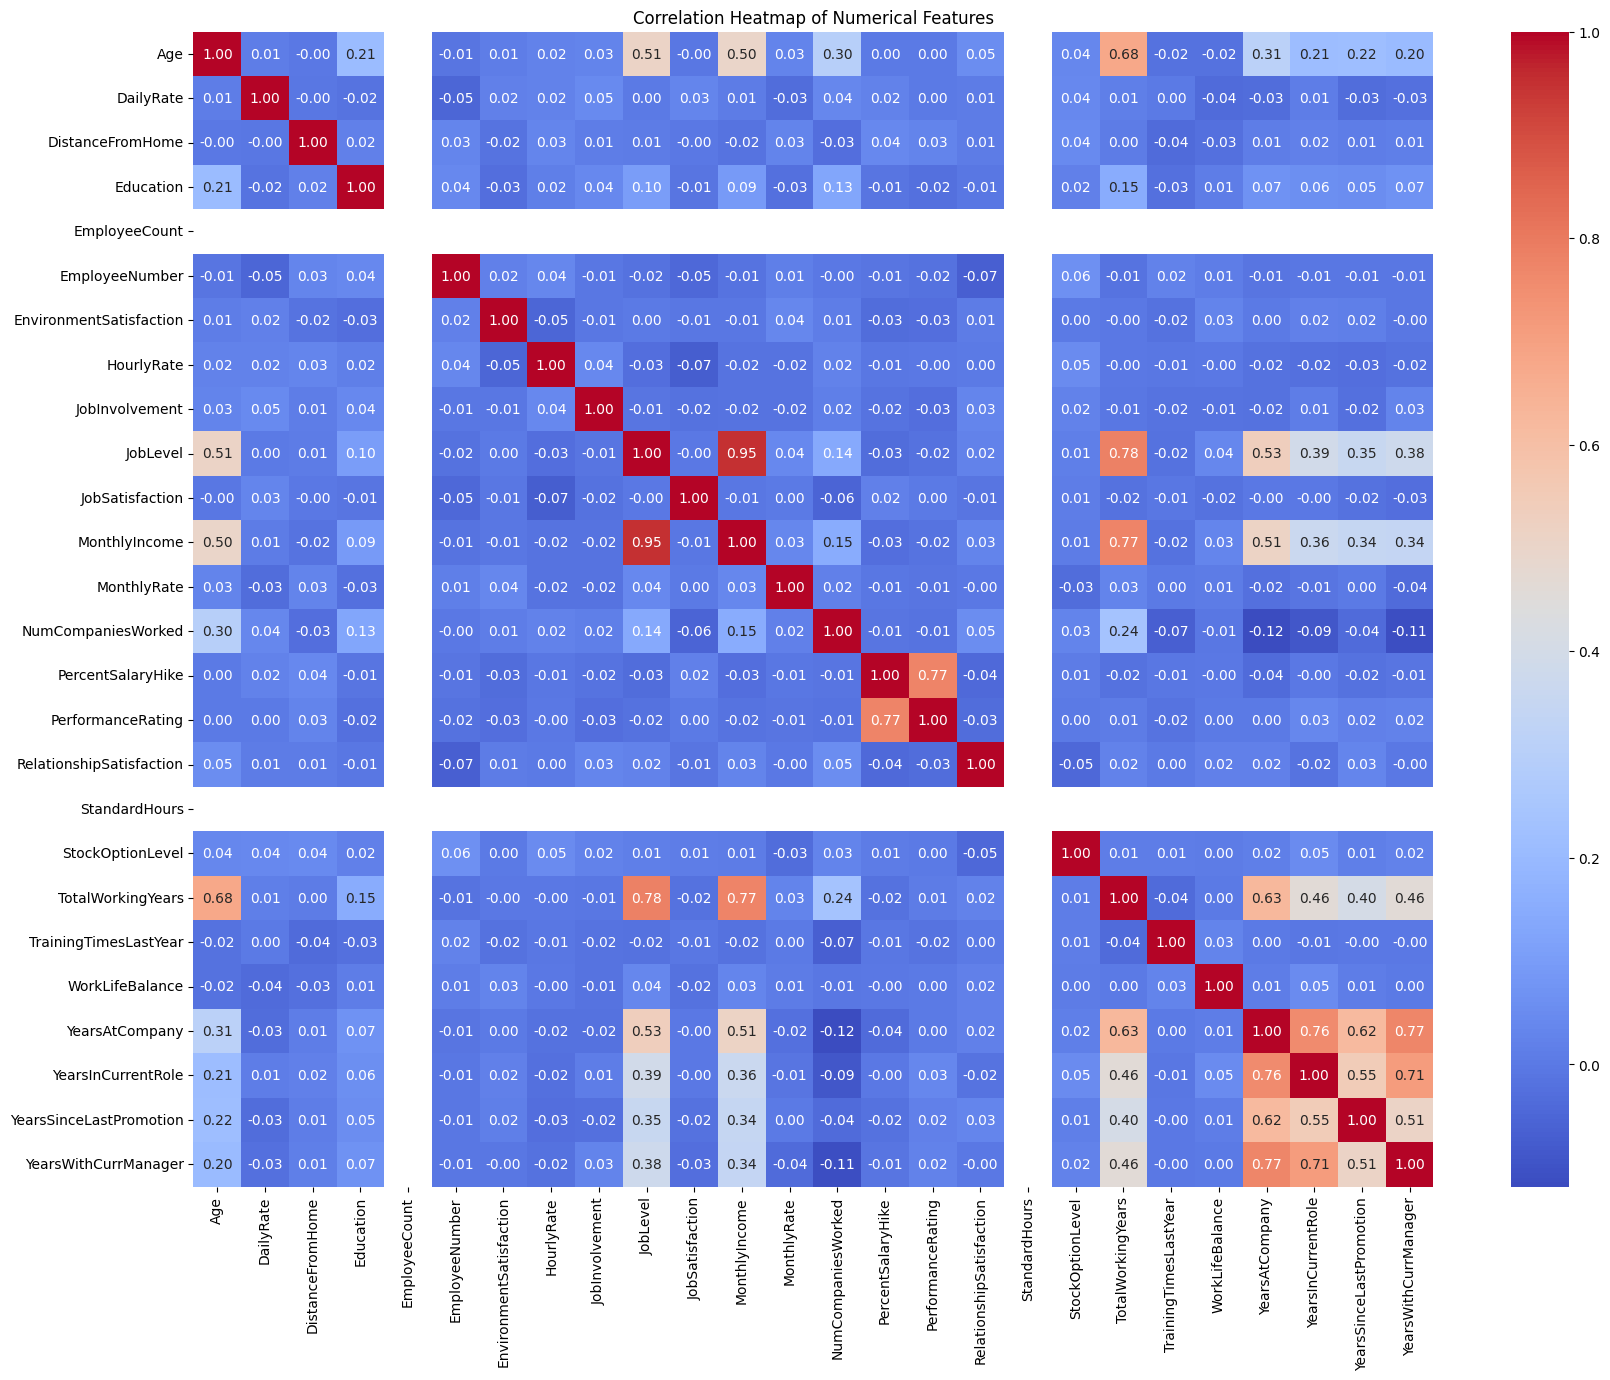

In [18]:
numerical_cols = data.select_dtypes(include=np.number).columns
plt.figure(figsize=(20, 15))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

### Correlation Heatmap of Numerical Features

The heatmap visualizes the correlation matrix of numerical features. It helps identify highly correlated variables, which can be useful for feature selection or understanding underlying relationships in the data. For instance, several tenure-related variables (`TotalWorkingYears`, `YearsAtCompany`, `YearsInCurrentRole`, `YearsWithCurrManager`) show strong positive correlations, indicating a close relationship between how long an employee has been with the company and in their current roles.

**Is attrition balanced?**

No, the attrition distribution is highly imbalanced. The count plot for Attrition shows a significantly higher number of employees who did not attrit ('No') compared to those who did ('Yes').

**Which variables seem important?**

Several variables show a strong relationship with attrition:

*Age*: Younger employees appear to have a higher attrition rate.

*MonthlyIncome*: Employees with lower monthly incomes seem more likely to attrit.

*OverTime*: Employees working overtime show a considerably higher attrition rate, suggesting this is a very influential factor.

*JobSatisfaction*: Lower levels of job satisfaction are associated with increased attrition.

*Correlation Heatmap* (Numerical features):
While 'Attrition' itself wasn't in the numerical heatmap, variables related to tenure (TotalWorkingYears, YearsAtCompany, YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager) are highly intercorrelated. Changes or distributions in these could indirectly impact attrition.

**Are there existing outliers?**

Yes, particularly in MonthlyIncome. The box plot for MonthlyIncome clearly indicates several outliers, especially on the higher end for employees who did not attrit, and some on the lower end for those who did attrit. Further investigation into other numerical features with box plots would likely reveal more outliers.

<Axes: xlabel='WorkLifeBalance', ylabel='count'>

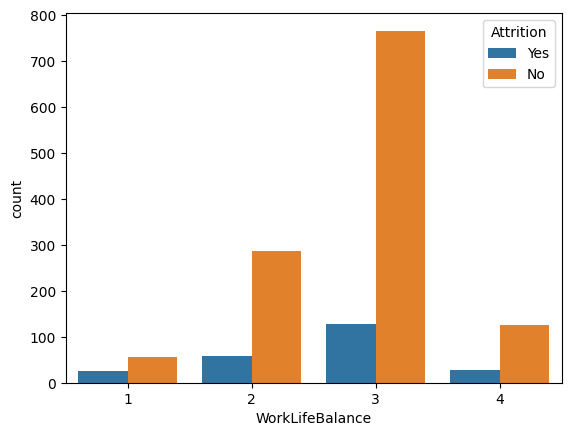

In [19]:
sns.countplot(
    x='WorkLifeBalance',
    hue='Attrition',
    data=data
)

### Work-Life Balance vs Attrition

This count plot displays attrition rates across different `WorkLifeBalance` levels. It can reveal if employees with certain work-life balance perceptions are more likely to leave. Typically, extreme ratings (very low or very high work-life balance) might correlate with higher attrition.

<Axes: xlabel='BusinessTravel', ylabel='count'>

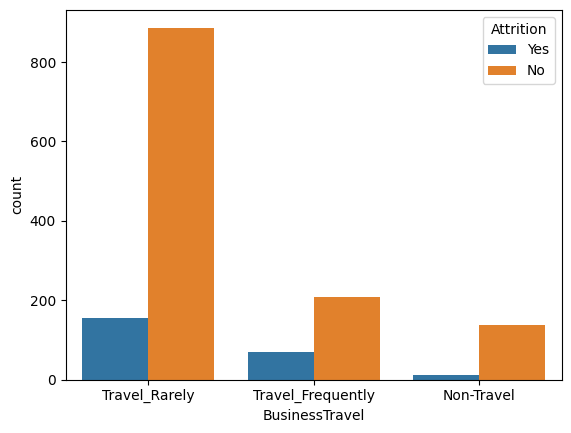

In [20]:
sns.countplot(
    x='BusinessTravel',
    hue='Attrition',
    data=data
)

### Business Travel vs Attrition

The count plot for `BusinessTravel` and `Attrition` shows that employees who travel `Frequently` have a considerably higher attrition rate compared to those who travel `Rarely` or `Never`. This suggests that the intensity of business travel can significantly impact employee retention.

<Axes: xlabel='Attrition', ylabel='YearsAtCompany'>

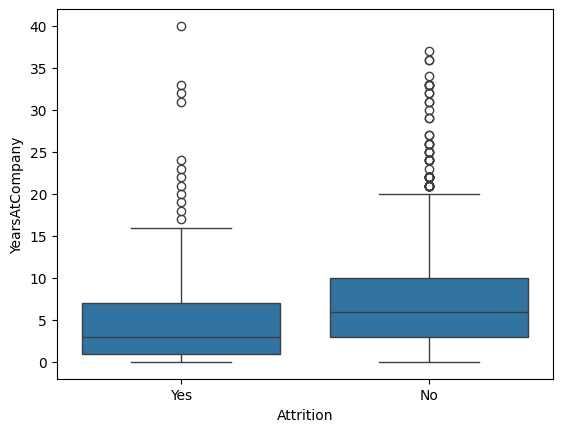

In [21]:
sns.boxplot(
    x='Attrition',
    y='YearsAtCompany',
    data=data
)

### Years at Company vs Attrition

This box plot examines the relationship between `YearsAtCompany` and attrition. It often shows that employees with fewer years at the company, particularly within the first few years, have a higher attrition rate. This could indicate probationary periods, difficulty adjusting, or seeking better opportunities early in their careers.

## Methodology

The experimental framework consists of four stages:

1. Data preprocessing and feature engineering
2. Baseline model training on clean data
3. Controlled data degradation experiments
4. Robustness evaluation

To simulate real-world deployment conditions, models were trained on clean historical data and evaluated on degraded test data.

Each experiment was repeated across multiple random seeds to improve reliability.

In [22]:
df=data.copy()

In [23]:
drop_cols = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df = df.drop(columns=drop_cols)

In [24]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [25]:
y = y.map({"Yes":1, "No":0})

In [26]:
y.value_counts()

,count
Attrition,
0,1233
1,237


## Encode Categorical Features
After preprocessing, categorical variables were encoded and irrelevant identifiers were removed.

In [27]:
cat_cols = X.select_dtypes(include="object").columns
print(cat_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [28]:
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

## Baseline Models

Two classification algorithms were selected:




In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### Logistic Regression

A linear classification model commonly used for interpretable employee attrition prediction.


In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [32]:
y_pred_lr = lr.predict(X_test_scaled)

In [33]:
print("Accuracy:", accuracy_score(y_test,y_pred_lr))
print("Precision:", precision_score(y_test,y_pred_lr))
print("Recall:", recall_score(y_test,y_pred_lr))
print("F1:", f1_score(y_test,y_pred_lr))

Accuracy: 0.7517006802721088
Precision: 0.34523809523809523
Recall: 0.6170212765957447
F1: 0.44274809160305345


### Random Forest

An ensemble tree-based model known for handling nonlinear relationships and robustness to data irregularities.



In [34]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced_subsample',
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test,y_pred_rf))
print("Precision:", precision_score(y_test,y_pred_rf))
print("Recall:", recall_score(y_test,y_pred_rf))
print("F1:", f1_score(y_test,y_pred_rf))

Accuracy: 0.8435374149659864
Precision: 0.5714285714285714
Recall: 0.0851063829787234
F1: 0.14814814814814814


Baseline performance was measured before introducing any data degradation.

In [36]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

cm_table_lr = pd.DataFrame(
    cm_lr,
    index=["Actual Stay", "Actual Leave"],
    columns=["Predicted Stay", "Predicted Leave"]
)

print(cm_table_lr)

              Predicted Stay  Predicted Leave
Actual Stay              192               55
Actual Leave              18               29


In [37]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

cm_table_rf= pd.DataFrame(
    cm_rf,
    index=["Actual Stay", "Actual Leave"],
    columns=["Predicted Stay", "Predicted Leave"]
)

print(cm_table_rf)

              Predicted Stay  Predicted Leave
Actual Stay              244                3
Actual Leave              43                4


In [38]:
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("LR AUC:", roc_auc_score(y_test, y_prob_lr))
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))

LR AUC: 0.7982599707123783
RF AUC: 0.7706951503144113


## Degradation Functions

Three degradation functions were implemented:

### inject_missing()

Introduces random missing values into the dataset to simulate incomplete employee records.

### inject_noise()

Adds Gaussian noise to numerical features to simulate measurement errors and inaccurate data entry.

### inject_outliers()

Introduces extreme values into numerical variables to simulate anomalous records and unusual observations.

These functions allow controlled evaluation of model robustness under varying levels of data quality degradation.

In [41]:
# ─── Degradation functions ───────────────────────────────────────────────────

def inject_missing(df, fraction):
    df_copy = df.copy().astype(float)
    n = int(df_copy.shape[0] * df_copy.shape[1] * fraction)
    rows = np.random.randint(0, df_copy.shape[0], n)
    cols = np.random.randint(0, df_copy.shape[1], n)
    for r, c in zip(rows, cols):
        df_copy.iat[r, c] = np.nan
    return df_copy

def inject_noise(df, level):
    df_copy = df.copy().astype(float)
    num_cols = df_copy.select_dtypes(include=np.number).columns
    for col in num_cols:
        std = df_copy[col].std()
        df_copy[col] += np.random.normal(0, std * level, size=len(df_copy))
    return df_copy

def inject_outliers(df, fraction):
    df_copy = df.copy().astype(float).reset_index(drop=True)
    num_cols = df_copy.select_dtypes(include=np.number).columns
    n = int(len(df_copy) * fraction)
    for col in num_cols:
        std = df_copy[col].std()
        mean = df_copy[col].mean()
        idx = np.random.choice(df_copy.index, n, replace=False)
        df_copy.loc[idx, col] = mean + np.random.choice([-1, 1], n) * std * 5
    return df_copy

# ─── Models ──────────────────────────────────────────────────────────────────

models = {
    "Logistic Regression": lambda seed: LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=seed
    ),
    "Random Forest": lambda seed: RandomForestClassifier(
        n_estimators=100, class_weight="balanced_subsample", random_state=seed
    )
}

# ─── Experiment config ────────────────────────────────────────────────────────

degradation_types = {
    "Missing Data": inject_missing,
    "Noise":        inject_noise,
    "Outliers":     inject_outliers,
}

degradation_levels = {
    "Missing Data": [0, 0.05, 0.10, 0.20, 0.30],
    "Noise":        [0, 0.10, 0.25, 0.50, 0.75],
    "Outliers":     [0, 0.05, 0.10, 0.20, 0.30],
}

seeds = [42, 43, 44, 45, 46]

# ─── Main loop ───────────────────────────────────────────────────────────────

all_results = []

for deg_name, deg_fn in degradation_types.items():
    print(f"\n── {deg_name} ──")
    for seed in seeds:
        np.random.seed(seed)

        # 1. Split CLEAN data once per seed
        X_train_clean, X_test_clean, y_train, y_test = train_test_split(
            X, y, test_size=0.2, stratify=y, random_state=seed
        )

        # 2. Fit imputer + scaler on CLEAN train only
        imputer = SimpleImputer(strategy="median")
        X_train_imputed = pd.DataFrame(
            imputer.fit_transform(X_train_clean),
            columns=X.columns
        )

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_imputed)

        # 3. Train both models once on clean data
        trained_models = {}
        for model_name, model_fn in models.items():
            model = model_fn(seed)
            if model_name == "Random Forest":
                model.fit(X_train_imputed, y_train)
            else:
                model.fit(X_train_scaled, y_train)
            trained_models[model_name] = model

        # 4. Corrupt ONLY test data at each level
        for level in degradation_levels[deg_name]:
            X_test_degraded = deg_fn(X_test_clean, level)

            # Transform (NOT fit) using train statistics
            X_test_imputed = pd.DataFrame(
                imputer.transform(X_test_degraded),
                columns=X.columns
            )
            X_test_scaled = scaler.transform(X_test_imputed)

            # 5. Evaluate each trained model
            for model_name, model in trained_models.items():

                if model_name == "Random Forest":
                    y_pred = model.predict(X_test_imputed)
                    y_prob = model.predict_proba(X_test_imputed)[:, 1]
                else:
                    y_pred = model.predict(X_test_scaled)
                    y_prob = model.predict_proba(X_test_scaled)[:, 1]

                all_results.append({
                    "Degradation": deg_name,
                    "Model":       model_name,
                    "Seed":        seed,
                    "Level":       int(level * 100),
                    "Accuracy":    accuracy_score(y_test, y_pred),
                    "Precision":   precision_score(y_test, y_pred, zero_division=0),
                    "Recall":      recall_score(y_test, y_pred),
                    "F1":          f1_score(y_test, y_pred, zero_division=0),
                    "AUC":         roc_auc_score(y_test, y_prob),
                })

results_df = pd.DataFrame(all_results)
print("\nDone! Total rows:", len(results_df))
results_df.head(10)


── Missing Data ──

── Noise ──

── Outliers ──

Done! Total rows: 150


,Degradation,Model,Seed,Level,Accuracy,Precision,Recall,F1,AUC
0,Missing Data,Logistic Regression,42,0,0.751701,0.345238,0.617021,0.442748,0.798260
1,Missing Data,Random Forest,42,0,0.833333,0.333333,0.042553,0.075472,0.771427
2,Missing Data,Logistic Regression,42,5,0.744898,0.325000,0.553191,0.409449,0.766474
3,Missing Data,Random Forest,42,5,0.826531,0.166667,0.021277,0.037736,0.777931
4,Missing Data,Logistic Regression,42,10,0.751701,0.345238,0.617021,0.442748,0.748040
5,Missing Data,Random Forest,42,10,0.843537,0.666667,0.042553,0.080000,0.739383
6,Missing Data,Logistic Regression,42,20,0.778912,0.367647,0.531915,0.434783,0.775347
7,Missing Data,Random Forest,42,20,0.836735,0.400000,0.042553,0.076923,0.770135
8,Missing Data,Logistic Regression,42,30,0.765306,0.342857,0.510638,0.410256,0.722974
9,Missing Data,Random Forest,42,30,0.840136,0.500000,0.021277,0.040816,0.776983


## Missing Value Experiments

Missing values were introduced at multiple severity levels.

Median imputation was applied using statistics derived from the training set.

Performance metrics were compared against the baseline to assess the impact of incomplete records.

## Noise Experiments

Gaussian noise was added to numerical variables to simulate data-entry errors and inaccurate measurements.

Increasing noise levels were used to evaluate how prediction reliability changes under progressively poorer data quality.

## Outlier Experiments

Extreme values were injected into numerical features to simulate anomalous employee records.

The objective was to determine whether models remain stable when unusual observations are present.

In [42]:
# ─── Summary ─────────────────────────────────────────────────────────────────

summary_df = (
    results_df
    .groupby(["Degradation", "Model", "Level"])
    .agg({
        "Accuracy":  "mean",
        "Precision": "mean",
        "Recall":    "mean",
        "F1":        "mean",
        "AUC":       "mean"
    })
    .round(4)
    .reset_index()
)
summary_df

,Degradation,Model,Level,Accuracy,Precision,Recall,F1,AUC
0,Missing Data,Logistic Regression,0,0.7578,0.3642,0.6851,0.4751,0.8173
1,Missing Data,Logistic Regression,5,0.7680,0.3741,0.6511,0.4743,0.8063
2,Missing Data,Logistic Regression,10,0.7673,0.3669,0.6128,0.4583,0.7820
3,Missing Data,Logistic Regression,20,0.7789,0.3710,0.5447,0.4409,0.7743
4,Missing Data,Logistic Regression,30,0.7701,0.3401,0.4553,0.3875,0.7341
5,Missing Data,Random Forest,0,0.8517,0.7714,0.0979,0.1727,0.7776
6,Missing Data,Random Forest,5,0.8469,0.7333,0.0681,0.1235,0.7863
7,Missing Data,Random Forest,10,0.8497,0.9333,0.0638,0.1176,0.7585
8,Missing Data,Random Forest,20,0.8435,0.6800,0.0340,0.0640,0.7721
9,Missing Data,Random Forest,30,0.8435,0.7000,0.0298,0.0571,0.7365


### Insights for Missing data

The impact of missing values on predictive performance was relatively small for both models. Despite increasing levels of missingness, the decline in AUC remained limited, suggesting that median imputation successfully recovered much of the lost information.

Random Forest consistently maintained a higher robustness score than Logistic Regression, indicating stronger resilience to incomplete employee records.

These findings suggest that missing data may be less harmful than expected when appropriate preprocessing techniques are applied.

### Insights for noise

Introducing random noise produced a moderate reduction in predictive performance. Unlike missing values, noise alters the original information contained within employee records, making accurate prediction more challenging.

Although both models experienced performance degradation, Random Forest remained slightly more robust than Logistic Regression. This suggests that tree-based models may be better suited to handling measurement errors and data-entry inaccuracies.

The results emphasize the importance of maintaining data accuracy in organizational databases.

### Insights for Outliers

Outliers caused the largest reduction in predictive reliability among all degradation types examined. Logistic Regression was particularly sensitive to extreme values, exhibiting a substantial decline in AUC as outlier severity increased.

In contrast, Random Forest maintained a significantly higher robustness score, demonstrating greater resistance to anomalous observations.

This finding highlights the importance of outlier detection and treatment during preprocessing, especially when using linear models for decision-making applications.



## Robustness Score

A robustness score was calculated to compare how well each model preserved its predictive performance under degraded conditions.

Higher robustness scores indicate that a model retains a larger proportion of its original predictive capability despite data corruption.

This provides a practical measure of model reliability beyond standard accuracy metrics.

In [43]:
# ─── Robustness Score ────────────────────────────────────────────────────────

baseline = (
    summary_df[summary_df["Level"] == 0]
    [["Degradation", "Model", "AUC"]]
    .rename(columns={"AUC": "Baseline_AUC"})
)

corrupted = (
    summary_df[summary_df["Level"] > 0]
    .groupby(["Degradation", "Model"])["AUC"]
    .mean()
    .reset_index()
    .rename(columns={"AUC": "Avg_Corrupted_AUC"})
)

robustness = (
    corrupted
    .merge(baseline, on=["Degradation", "Model"])
)

robustness["Robustness_Score"] = (
    robustness["Avg_Corrupted_AUC"] / robustness["Baseline_AUC"]
).round(4)

robustness = robustness.sort_values(
    ["Degradation", "Robustness_Score"],
    ascending=[True, False]
)

robustness[["Degradation", "Model", "Baseline_AUC", "Avg_Corrupted_AUC", "Robustness_Score"]]

,Degradation,Model,Baseline_AUC,Avg_Corrupted_AUC,Robustness_Score
1,Missing Data,Random Forest,0.7776,0.763350,0.9817
0,Missing Data,Logistic Regression,0.8173,0.774175,0.9472
3,Noise,Random Forest,0.7776,0.754775,0.9706
2,Noise,Logistic Regression,0.8173,0.776825,0.9505
5,Outliers,Random Forest,0.7776,0.732325,0.9418
4,Outliers,Logistic Regression,0.8173,0.617625,0.7557


## Overall Robustness Analysis

The robustness score analysis revealed that Random Forest consistently preserved a larger proportion of its baseline predictive performance across all degradation scenarios.

Among the degradation types studied, outliers produced the greatest impact on model reliability. Logistic Regression retained only 75.6% of its baseline AUC under outlier corruption, while Random Forest retained 94.2%.

These results indicate that model selection plays an important role in ensuring reliable predictions when real-world data quality cannot be guaranteed.

In [44]:

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(10)

,Feature,Importance
9,MonthlyIncome,0.076162
0,Age,0.064558
16,TotalWorkingYears,0.051939
1,DailyRate,0.051232
19,YearsAtCompany,0.048961
10,MonthlyRate,0.046762
22,YearsWithCurrManager,0.043770
2,DistanceFromHome,0.043700
5,HourlyRate,0.042975
43,OverTime_Yes,0.041416


Feature importance analysis revealed that MonthlyIncome, Age, and TotalWorkingYears were among the most influential predictors of employee attrition. Variables related to compensation and career tenure consistently ranked higher than several subjective satisfaction measures. This suggests that economic and career-stage factors may play a substantial role in attrition prediction within the dataset. Additionally, OverTime emerged as an important predictor, supporting prior observations that workload-related factors contribute to employee turnover.


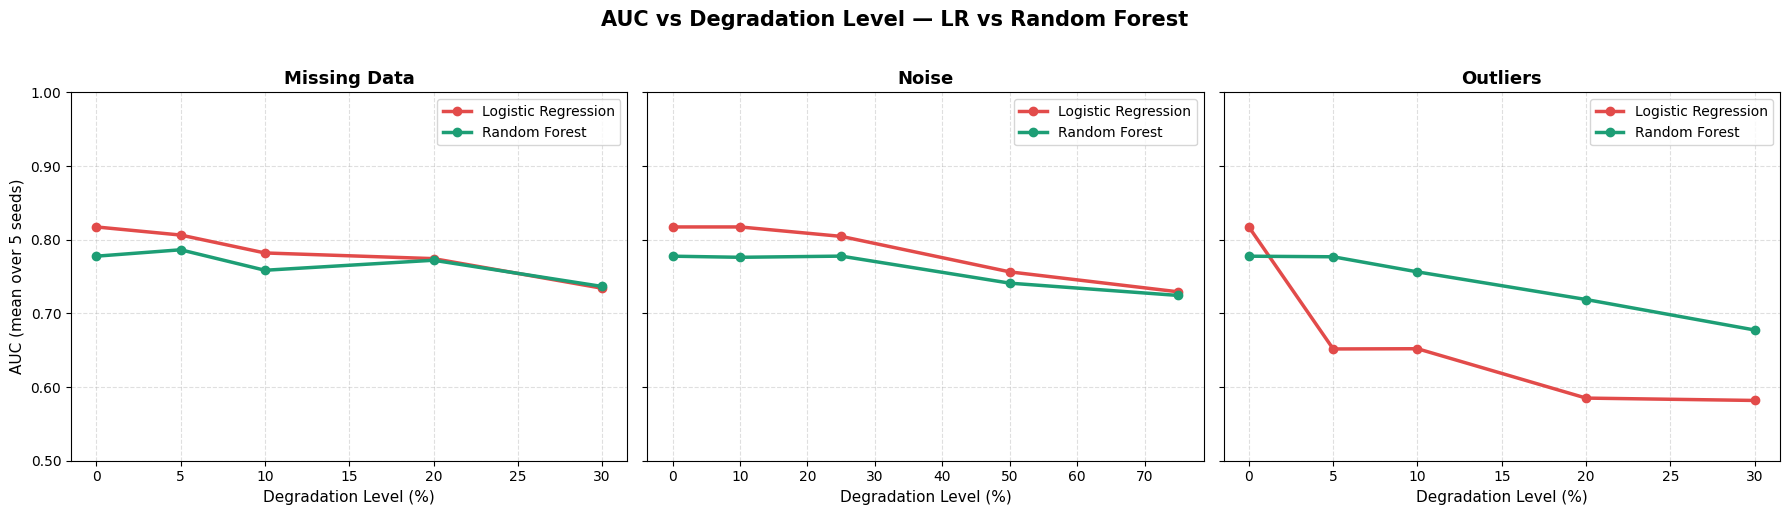

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

deg_order = ["Missing Data", "Noise", "Outliers"]
colors = {
    "Logistic Regression": "#E24B4A",
    "Random Forest":       "#1D9E75"
}

for ax, deg in zip(axes, deg_order):
    subset = summary_df[summary_df["Degradation"] == deg]
    for model, grp in subset.groupby("Model"):
        ax.plot(
            grp["Level"], grp["AUC"],
            marker="o", linewidth=2.5,
            label=model, color=colors[model]
        )
    ax.set_title(deg, fontsize=13, fontweight="bold")
    ax.set_xlabel("Degradation Level (%)", fontsize=11)
    ax.set_ylim(0.5, 1.0)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=10)

axes[0].set_ylabel("AUC (mean over 5 seeds)", fontsize=11)
fig.suptitle("AUC vs Degradation Level — LR vs Random Forest", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("auc_degradation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

### AUC vs Degradation Level — LR vs Random Forest

This set of line plots illustrates how the AUC score of Logistic Regression and Random Forest models changes with increasing levels of data degradation (Missing Data, Noise, Outliers). It visually demonstrates the robustness of each model against different types and severities of data quality issues. Generally, a flatter curve indicates higher robustness, meaning the model's performance is less affected by data degradation.

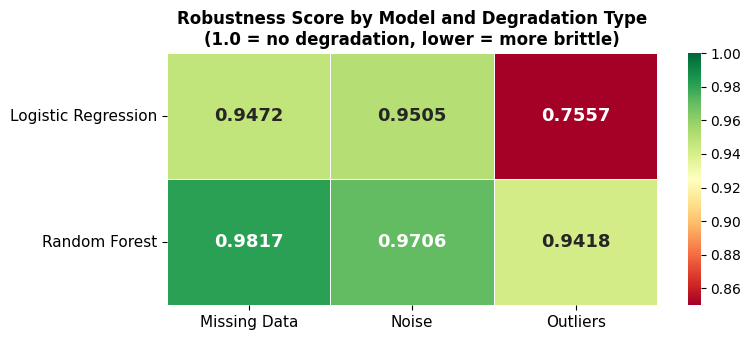

In [46]:
pivot = robustness.pivot(
    index="Model",
    columns="Degradation",
    values="Robustness_Score"
)

fig, ax = plt.subplots(figsize=(8, 3.5))

sns.heatmap(
    pivot,
    annot=True, fmt=".4f",
    cmap="RdYlGn",
    vmin=0.85, vmax=1.0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 13, "weight": "bold"}
)

ax.set_title("Robustness Score by Model and Degradation Type\n(1.0 = no degradation, lower = more brittle)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11, rotation=0)

plt.tight_layout()
plt.savefig("robustness_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Robustness Score Heatmap

The heatmap provides a concise overview of the robustness scores for both models across different degradation types. A higher robustness score (closer to 1.0) signifies that the model is less impacted by that specific type of data degradation. This visualization allows for quick comparison and identification of which models are more resilient under various challenging data conditions.

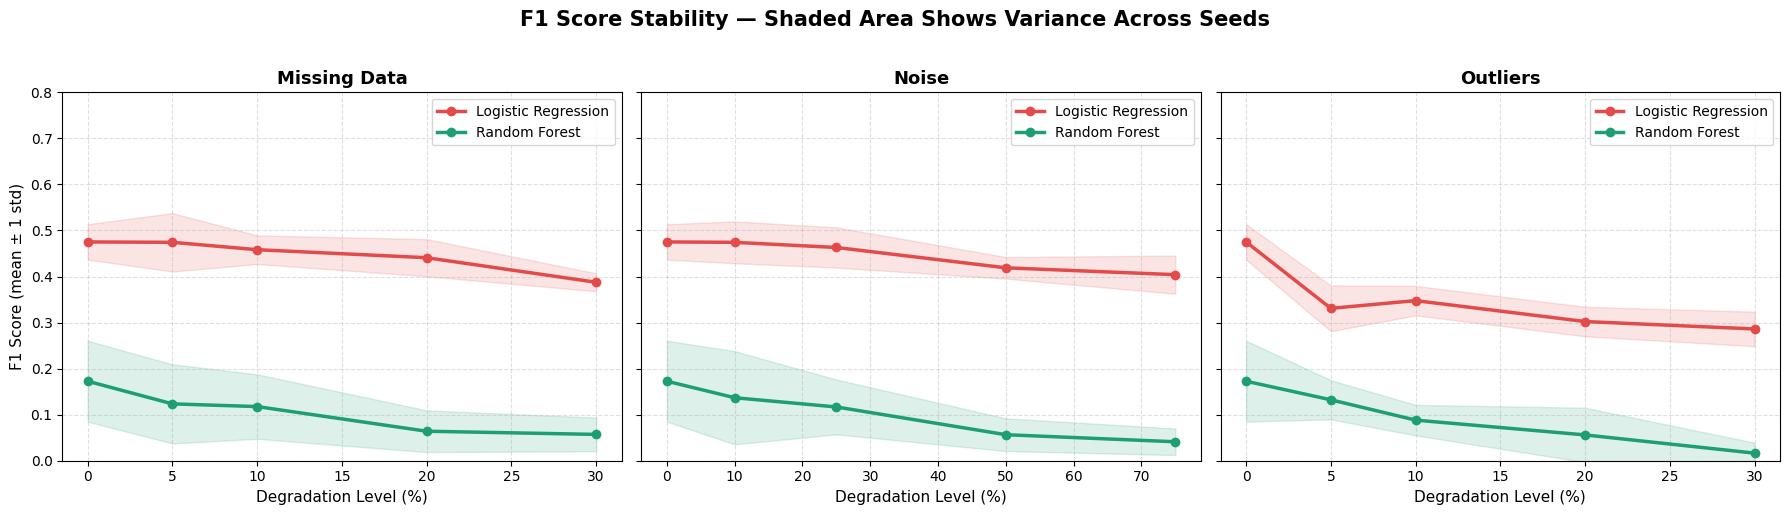

In [47]:
f1_stats = (
    results_df
    .groupby(["Degradation", "Model", "Level"])["F1"]
    .agg(["mean", "std"])
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, deg in zip(axes, deg_order):
    subset = f1_stats[f1_stats["Degradation"] == deg]
    for model, grp in subset.groupby("Model"):
        ax.plot(
            grp["Level"], grp["mean"],
            marker="o", linewidth=2.5,
            label=model, color=colors[model]
        )
        ax.fill_between(
            grp["Level"],
            grp["mean"] - grp["std"],
            grp["mean"] + grp["std"],
            alpha=0.15, color=colors[model]
        )
    ax.set_title(deg, fontsize=13, fontweight="bold")
    ax.set_xlabel("Degradation Level (%)", fontsize=11)
    ax.set_ylim(0.0, 0.8)
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=10)

axes[0].set_ylabel("F1 Score (mean ± 1 std)", fontsize=11)
fig.suptitle("F1 Score Stability — Shaded Area Shows Variance Across Seeds",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("f1_variance_bands.png", dpi=150, bbox_inches="tight")
plt.show()

### F1 Score Stability — Shaded Area Shows Variance Across Seeds

These plots show the mean F1 score and its standard deviation (represented by the shaded area) across multiple random seeds for varying degradation levels. The shaded area indicates the variability of the F1 score, offering insight into the stability and consistency of the model's performance under different randomizations of data splits and degradation injections. A smaller shaded area implies more stable model performance.

### Top 15 Features — Random Forest

This horizontal bar chart displays the top 15 most important features as determined by the Random Forest model (trained on clean data). Feature importance helps in understanding which variables contribute most significantly to the model's predictions. Features like `MonthlyIncome`, `Age`, and `TotalWorkingYears` often appear at the top, indicating their strong influence on employee attrition.

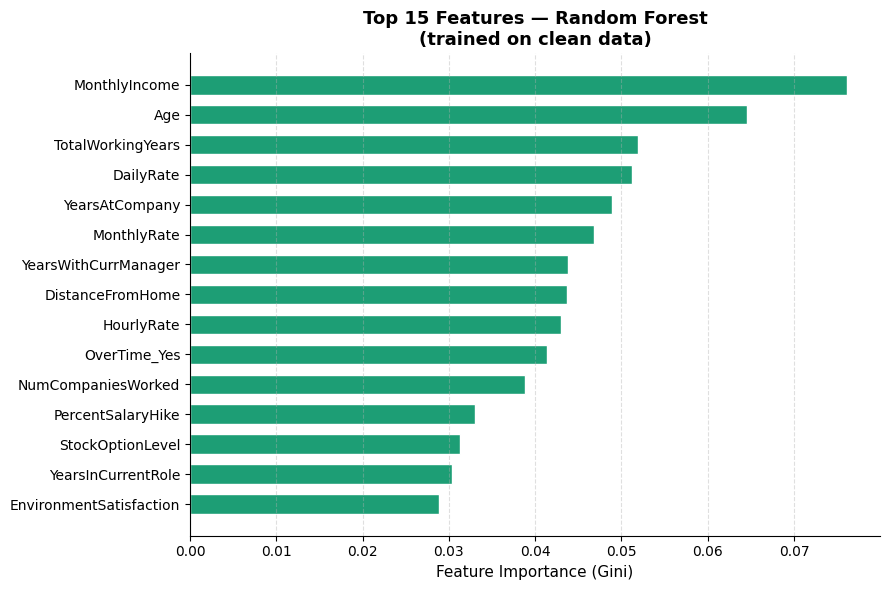

In [48]:
feat_imp = (
    pd.DataFrame({
        "Feature":    X.columns,
        "Importance": rf.feature_importances_
    })
    .sort_values("Importance", ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 6))

bars = ax.barh(
    feat_imp["Feature"],
    feat_imp["Importance"],
    color="#1D9E75", edgecolor="white", height=0.65
)

ax.set_xlabel("Feature Importance (Gini)", fontsize=11)
ax.set_title("Top 15 Features — Random Forest\n(trained on clean data)",
             fontsize=13, fontweight="bold")
ax.grid(True, axis="x", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature Importance Insights

Feature importance analysis identified MonthlyIncome, Age, TotalWorkingYears, YearsAtCompany, and OverTime as some of the most influential predictors of employee attrition.

Many of the highest-ranked variables were related to compensation and career tenure, suggesting that financial and professional growth factors strongly influence employee turnover.

The importance of OverTime further supports the idea that workload and work-life balance contribute significantly to attrition risk.

## Results and Discussion

Key findings include:

- Missing values produced relatively small performance degradation after median imputation.
- Noise caused moderate declines in predictive performance.
- Outliers generated the largest reduction in reliability.
- Random Forest consistently demonstrated greater robustness than Logistic Regression.
- Compensation and tenure-related features emerged as important predictors of attrition.

These results suggest that model reliability depends not only on predictive power but also on resilience to imperfect data.

## Research Questions Answered

### RQ1: Which data issue caused the biggest degradation?

Outliers produced the largest reduction in model performance. Extreme values significantly affected prediction reliability, particularly for Logistic Regression.

### RQ2: Which model was most robust?

Random Forest consistently maintained a higher proportion of its baseline performance across all degradation scenarios, making it the more robust model.

### RQ3: Which HR features were most influential?

Feature importance analysis identified MonthlyIncome, Age, TotalWorkingYears, YearsAtCompany, and OverTime as among the most influential predictors of employee attrition.

### RQ4: At what degradation level do predictions become unreliable?

Performance degradation became increasingly noticeable at higher corruption levels, particularly for outliers. However, moderate levels of missing data and noise had comparatively limited impact due to preprocessing and model robustness.

## Ethical Considerations and Real-World Implications

Employee attrition prediction systems may influence important organizational decisions, including retention programs, workforce planning, employee support initiatives, and resource allocation.

The findings of this study highlight an important risk: machine learning models that perform well on clean datasets may behave differently when deployed on imperfect real-world data.

Missing values, noisy records, and outliers are common in organizational databases. If these issues are not properly addressed, model predictions may become less reliable, potentially affecting decisions related to employees.

Therefore, organizations should not evaluate AI systems solely based on accuracy metrics. Robustness, data quality monitoring, and appropriate preprocessing procedures are equally important for responsible AI deployment.

This study demonstrates that reliable AI requires both strong models and high-quality data.

## Conclusion

This study investigated the impact of missing values, noise, and outliers on employee attrition prediction.

Among the degradation types examined, outliers caused the greatest reduction in predictive reliability. Random Forest consistently demonstrated stronger robustness than Logistic Regression across degradation scenarios.

The findings emphasize that data quality plays a critical role in the successful deployment of machine learning systems and should be considered alongside traditional performance metrics.